# Create delta-DG1 model

**Goal:**

Create a model for the DG1 model that uses a delta subinterval plus the CG1 interval for the bottom branch.

**Procedure:**
1. Create a new `create_model` function for the delta model.
2. Save the updated config for the new delta model.
3. Decide on alpha, term: Proportion of the cell cycle length similar to Xin's alpha value. (What is the literature on the estimated length of G1?)
4. Create a new calcH function to create the new delta H model.
    - (Will calcH just work with the new intervals?)
5. Plot the model diagram (validation)
6. Plot the growth diagram (validation)


In [11]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [74]:
from src.create_models_delta import create_wt1_model

alpha = 16
modelfile1 = create_wt1_model(f'models/yl_cell_cycle/wt1_rg1_delta.{alpha}.label', alpha)

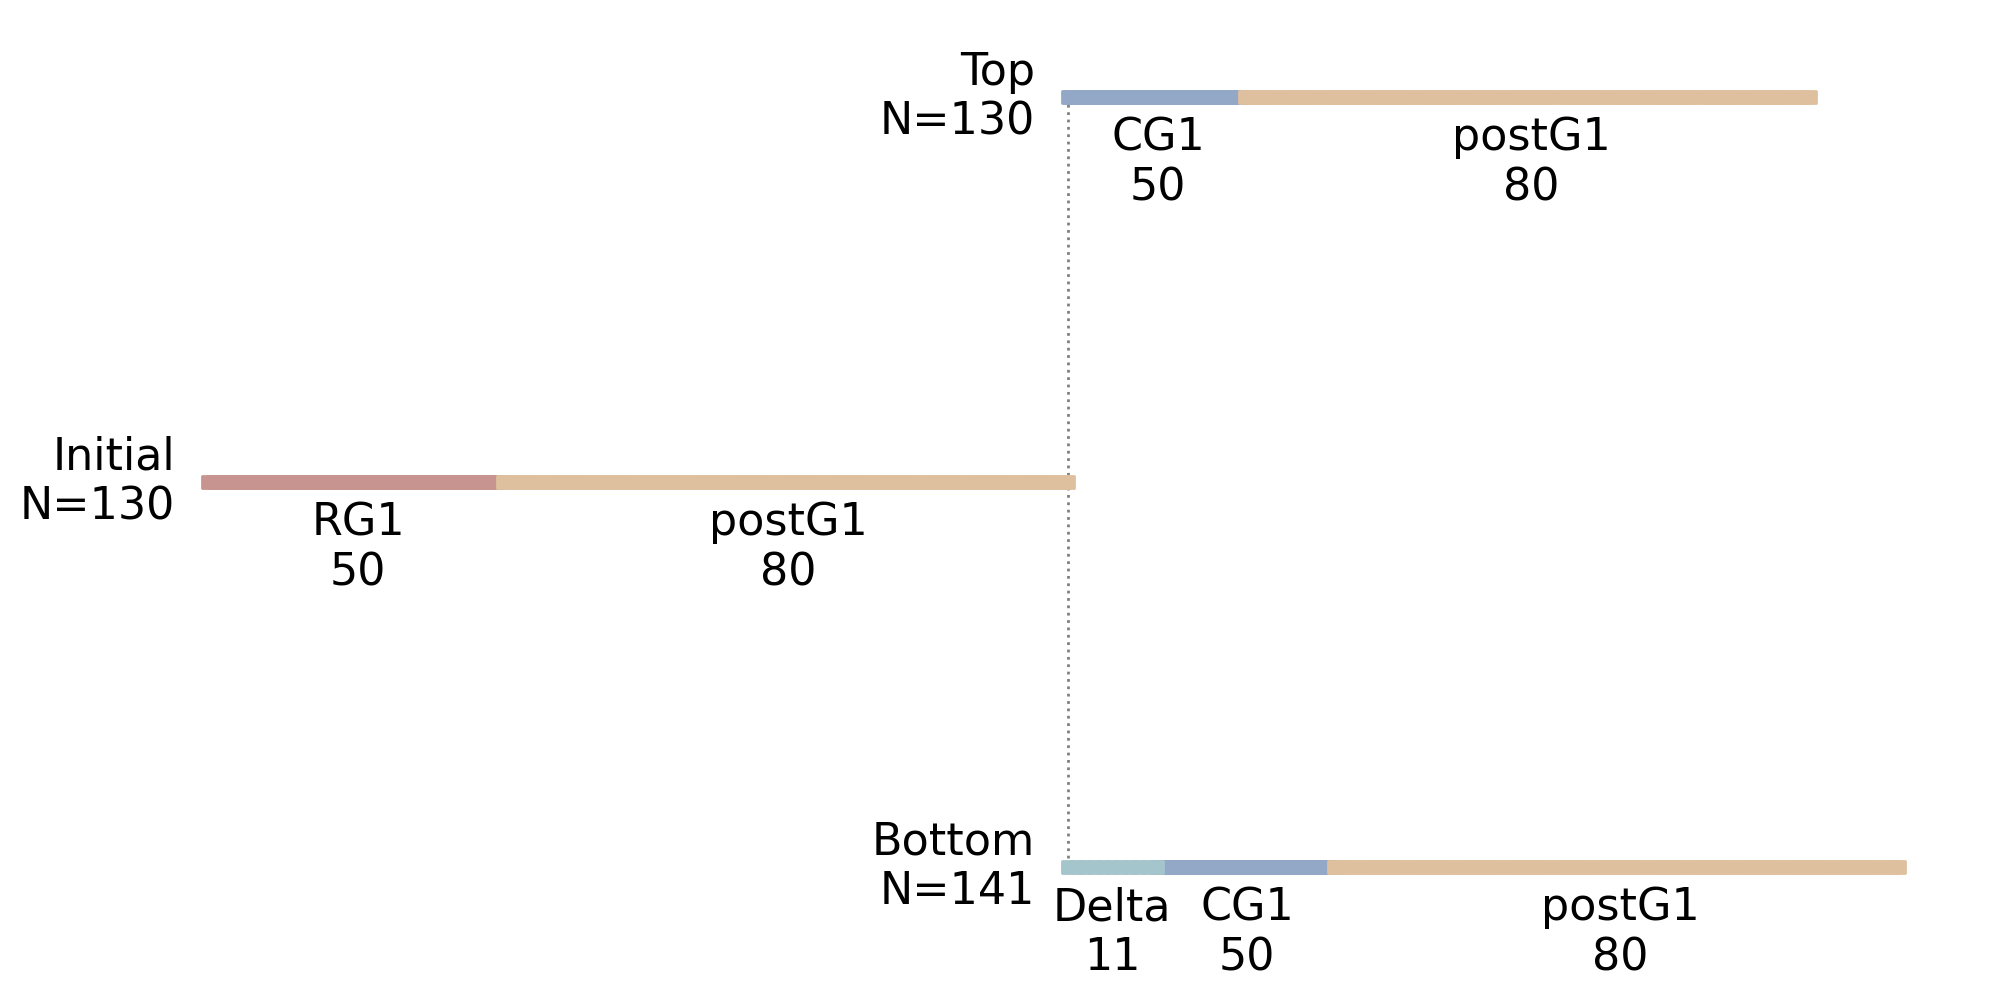

In [75]:
from src.ModelFile import ModelFile

model_file_loaded = ModelFile()
model_file_loaded.load_model(modelfile1)
model_file_loaded.plot_model()

In [79]:
# Create the H for the updated model config to include the H config
from src.delta_config import load_yl_delta_config
config = load_yl_delta_config(1)

In [82]:
from src.helpers import calcH
H, Hpositions = calcH(config.intervals_wt1, config.WT1_TIMEPOINTS)

Text(0.5, 1.0, 'DG1 H matrix')

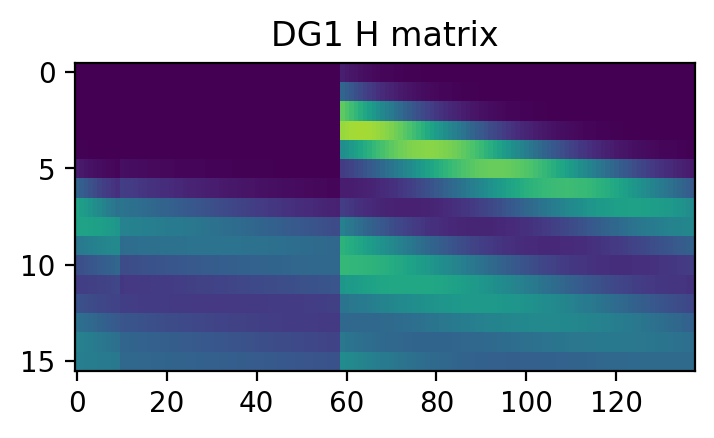

In [177]:
# Checking the DG1 is a smooth transition from the "Delta" phase 
# into CG1
plt.figure(figsize=(4, 2))
bottom_indices = config.get_Hpositions_for_branch('b')
bottom_H = H[:, bottom_indices]
plt.imshow(bottom_H, vmax=0.02, aspect='auto')
plt.title("DG1 H matrix")

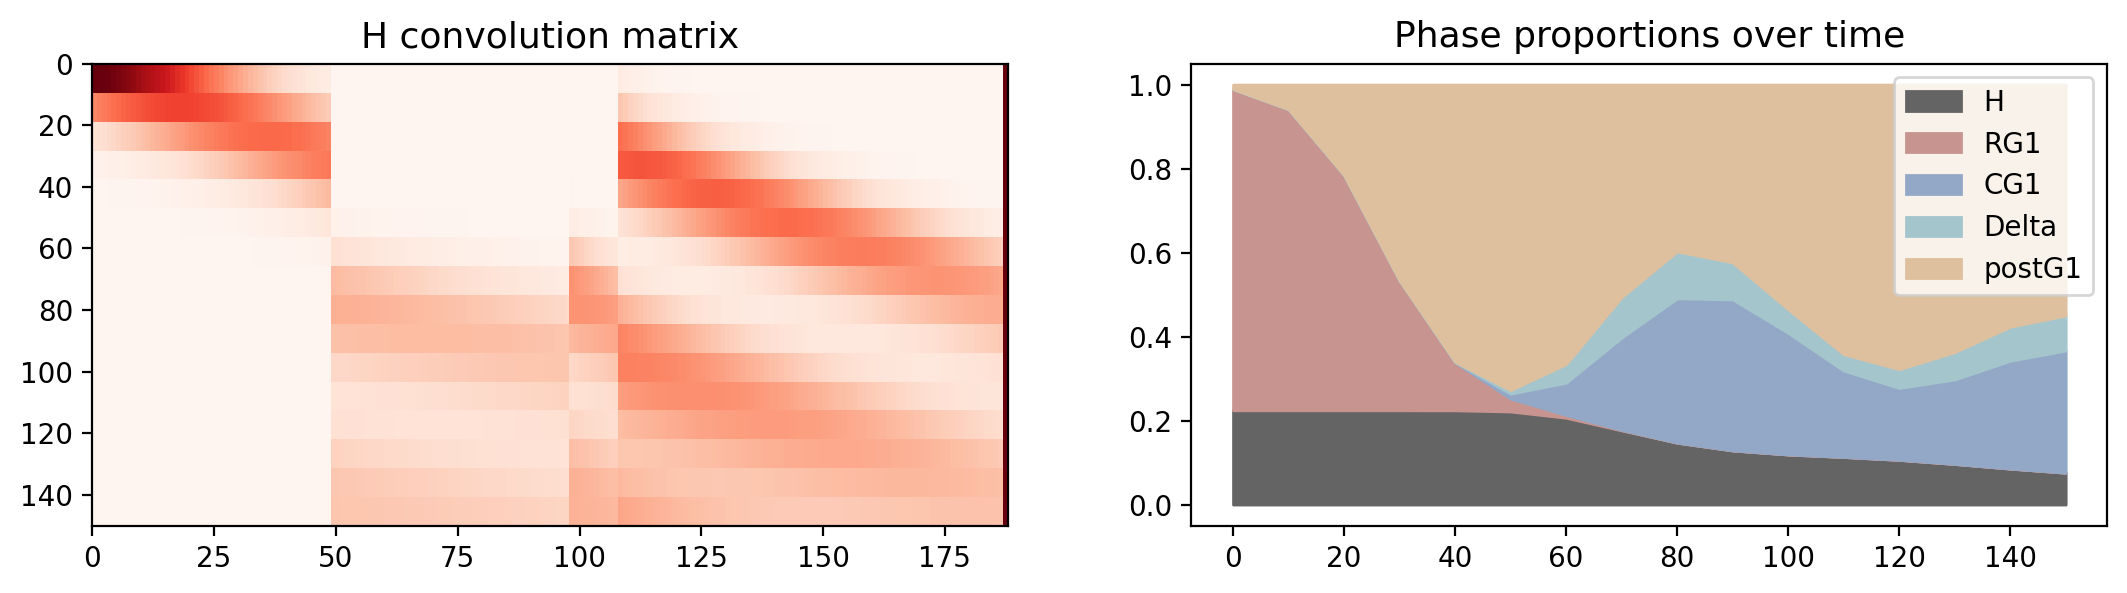

In [174]:
from src.config import plot_H
plot_H(config, H)

In [203]:
# Next deconvolve the gene expression for CLB2, DSE1, DSE2, and CLN1
# I expect the DSE genes to be affected the most, will the CG1 and DG1 look similar?
# What will the delta region look like?

# Then deconvolve all of the genes
from src.model import Model

model = Model(config, 'RAD53')

In [209]:
model.deconvolve_find_optimal_gamma()

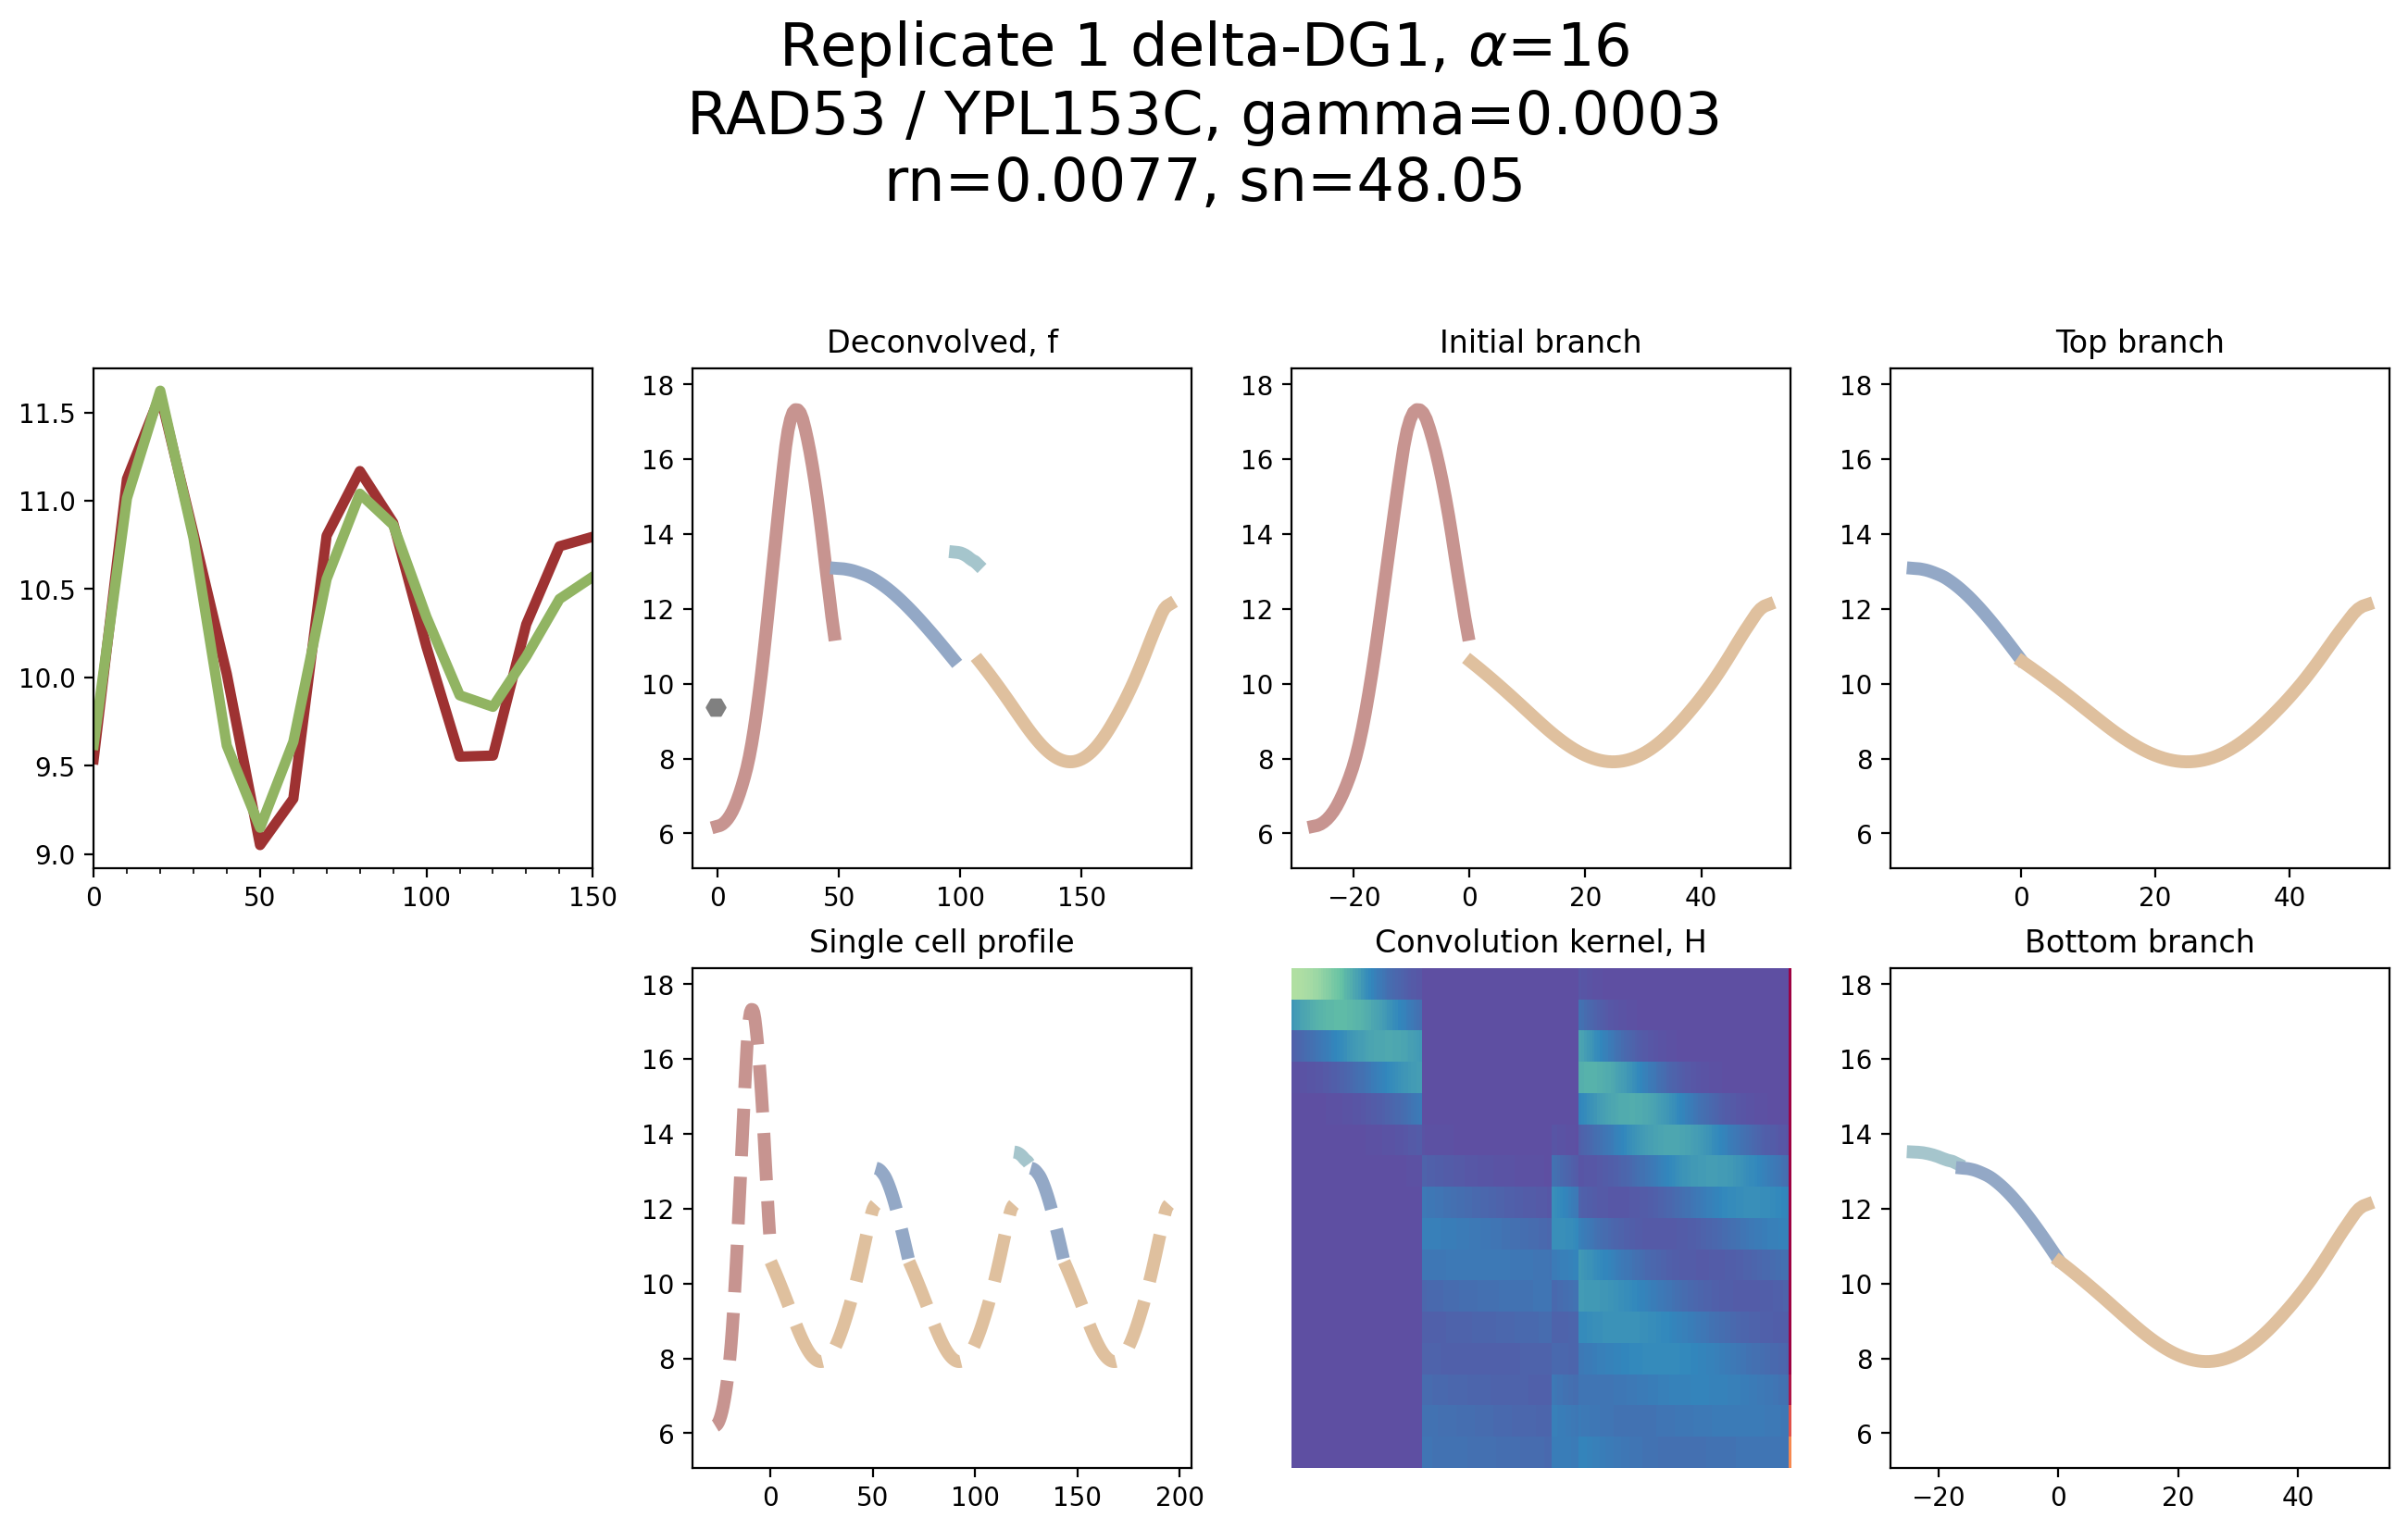

In [211]:
fig = model.plot_deconvolved_gene()

In [239]:
from src.chromatin_model import ChromatinModel

chrom_model = ChromatinModel(config)
chrom_model.load_mnase_gene('CLB2')
# Deconvolve the chromatin.

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


In [240]:
chrom_model.create_deconvolution_bins()
chrom_model.setup_deconv_model()
chrom_model.setup_solver()

In [241]:
chrom_model.deconvolve()

Deconvolving with gamma=0.006
Deconvolved in : 00:00:26.676
The fitting norm is 3.94, the smoothing norm is: 25.03


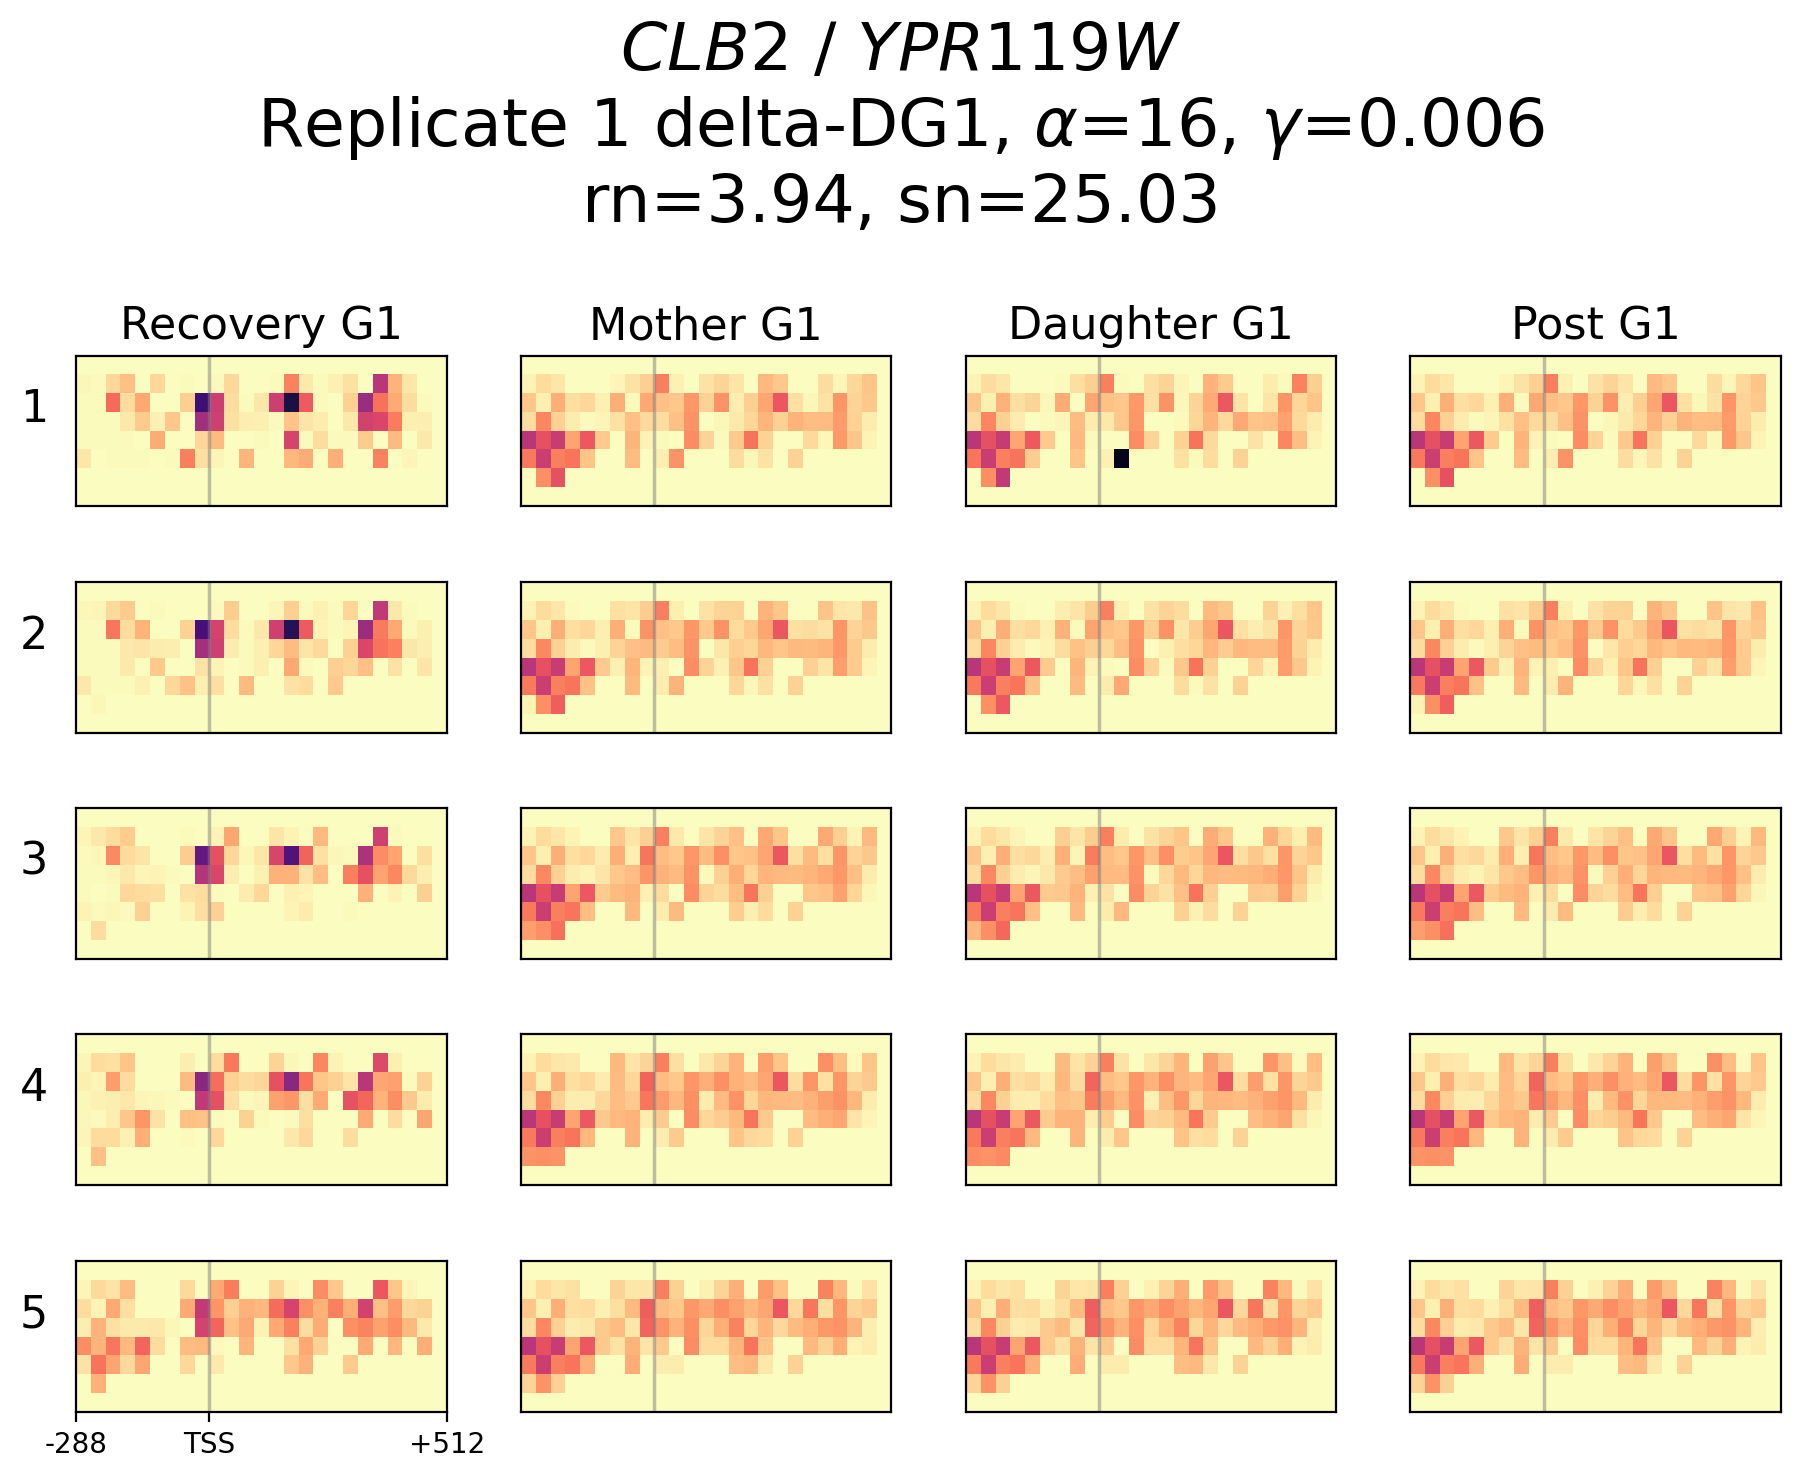

In [242]:
fig = chrom_model.create_deconvolution_plots_abbreviated_flipped()

In [243]:
chrom_model.deconv_hist_unflattened.shape

(16, 8, 25)